## Folder

In [84]:
import os

OUT_DIR = "analysis"
LOG_FILES = "data/20260417/1MHz_25percent.log"
# LOG_FILES = [
#     "data/20260417/1MHz_25percent.log",
# ]

## Unit conversion

In [85]:
# convert to unit byte (kilobyte, megabyte, gigabyte)
byte_units = {
    "Bytes"   : 1, 
    "KBytes"  : 1024,
    "MBytes"  : 1024*1024,
    "GBytes"  : 1024*1024*1024
}

# convert to unit bits/sec (kilobits, megabits, gigabits)
bit_units = {
    "bits/sec"  : 1,
    "Kbits/sec" : 1e3,
    "Mbits/sec" : 1e6,
    "Gbits/sec" : 1e9
}
# for the Transfer col
def to_bytes (val, unit):
    return val * byte_units[unit]
# for the Bitrate col
def to_mbits (val, unit):
    return val * bit_units[unit] / 1e6

## Regex processors

In [86]:
import re 

# Server listening on 5201 (test #n)
TEST_HEADER_RE = re.compile(r"Server listening on \d+ \(test #(\d+)\)")

# [  6]   0.00-1.00   sec  4.25 MBytes  35.6 Mbits/sec    8   35.4 KBytes
# [SUM]   0.00-1.00   sec  17.0 MBytes   142 Mbits/sec   51
INTERVAL_RE = re.compile(
    r"^\[\s*(?P<id>\d+|SUM)\]\s+"
    r"(?P<start>\d+\.\d+)-(?P<end>\d+\.\d+)\s+sec\s+"
    r"(?P<xfer_val>[\d.]+)\s+(?P<xfer_unit>[KMG]?Bytes)\s+"
    r"(?P<rate_val>[\d.]+)\s+(?P<rate_unit>[KMG]?bits/sec)"
    r"(?:\s+(?P<retr>\d+))?"
    r"(?:\s+(?P<cwnd_val>[\d.]+)\s+(?P<cwnd_unit>[KMG]?Bytes))?"
)

# [  6]   0.00-30.01  sec  63.8 MBytes  17.8 Mbits/sec  243            sender
# [SUM]   0.00-30.01  sec   323 MBytes  90.4 Mbits/sec  1175           sender
FINAL_RE = re.compile(
    r"^\[\s*(?P<id>\d+|SUM)\]\s+"
    r"(?P<start>\d+\.\d+)-(?P<end>\d+\.\d+)\s+sec\s+"
    r"(?P<xfer_val>[\d.]+)\s+(?P<xfer_unit>[KMG]?Bytes)\s+"
    r"(?P<rate_val>[\d.]+)\s+(?P<rate_unit>[KMG]?bits/sec)"
    r"(?:\s+(?P<retr>\d+))?"
    r"\s+(?P<role>sender|receiver)\s*$"
)

## Single file reader

It reads a log file and write it to a dataframe. 

In [87]:
import pandas as pd

intervals = []
finals = []
current_test = None

with open(LOG_FILES, "r") as f:
    for line in f: 
        line = line.strip()

        m = TEST_HEADER_RE.match(line)
        if m:
            current_test = int(m.group(1))
            continue
        if current_test is None:
            continue
        
        m = FINAL_RE.match(line)
        if m:
            finals.append({
                "test_id": current_test,
                "stream_id": m.group("id"),
                "start_s": float(m.group("start")),
                "end_s": float(m.group("end")),
                "transfer_bytes": to_bytes(float(m.group("xfer_val")), m.group("xfer_unit")),
                "bitrate_mbps": to_mbits(float(m.group("rate_val")), m.group("rate_unit")),
                "retr": int(m.group("retr")) if m.group("retr") else None,
                "cwnd_bytes": None,
                "kind": "final",
                "role": m.group("role"),
            })
            continue

        m = INTERVAL_RE.match(line)
        if m:
            cwnd = to_bytes(float(m.group("cwnd_val")), m.group("cwnd_unit")) \
                if m.group("cwnd_val") else None
            intervals.append({
                "test_id": current_test,
                "stream_id": m.group("id"),
                "start_s": float(m.group("start")),
                "end_s": float(m.group("end")),
                "transfer_bytes": to_bytes(float(m.group("xfer_val")), m.group("xfer_unit")),
                "bitrate_mbps": to_mbits(float(m.group("rate_val")), m.group("rate_unit")),
                "retr": int(m.group("retr")) if m.group("retr") else None,
                "cwnd_bytes": cwnd,
                "kind": "interval",
                "role": None,
            })

df_intervals = pd.DataFrame(intervals)
df_finals = pd.DataFrame(finals)

df_intervals
# df_finals

,test_id,stream_id,start_s,end_s,transfer_bytes,bitrate_mbps,retr,cwnd_bytes,kind,role
0,1,6,0.0,1.00,4456448.00,35.6,8,36249.6,interval,None
1,1,9,0.0,1.00,2359296.00,18.9,9,25088.0,interval,None
2,1,11,0.0,1.00,3019898.88,24.1,13,16691.2,interval,None
3,1,13,0.0,1.00,3795845.12,30.4,11,16691.2,interval,None
4,1,15,0.0,1.00,4194304.00,33.5,10,23654.4,interval,None
...,...,...,...,...,...,...,...,...,...,...
727,4,9,30.0,30.01,0.00,0.0,0,11161.6,interval,None
728,4,11,30.0,30.01,262144.00,212.0,0,18124.8,interval,None
729,4,13,30.0,30.01,262144.00,212.0,0,41779.2,interval,None
730,4,15,30.0,30.01,0.00,0.0,0,40448.0,interval,None


In [88]:
print(df_intervals["stream_id"].unique())

<StringArray>
['6', '9', '11', '13', '15', 'SUM']
Length: 6, dtype: str


## Plotting

For each test, we draw **three** plots stacked together, sharing the same x-axis.

1. A time series plot with the y-axis being bitrate (Mbits/sec). 
2. Second plot is a bar chart with the y-axis being retransmission count.
3. Third plot is a time series plot with the y-axis being congestion window size (Bytes). 

['6', '9', '11', '13', '15']


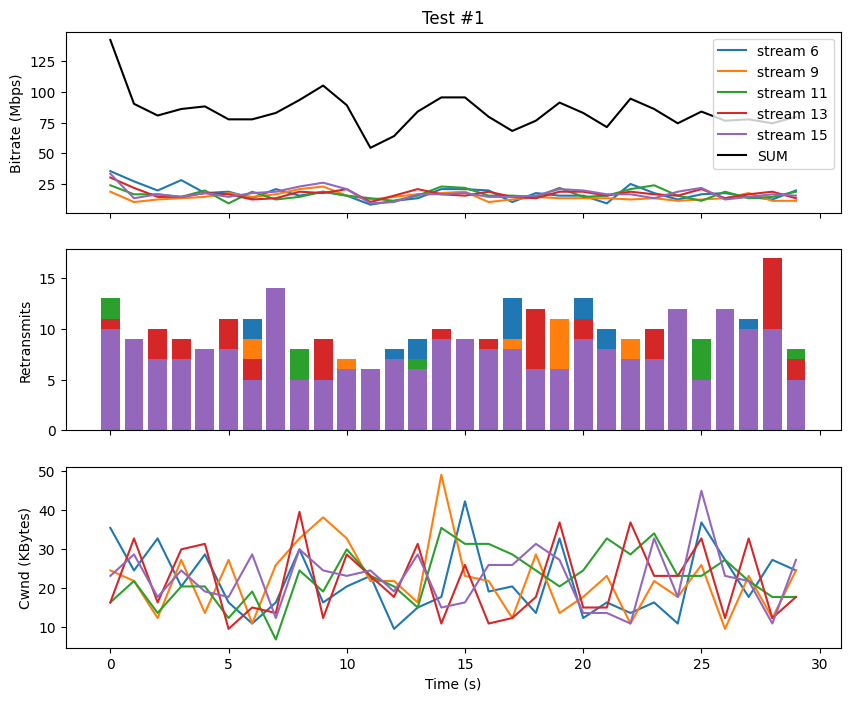

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# list of stream ids
stream_ids = sorted(
    [sid for sid in df_intervals["stream_id"].unique() if sid != "SUM"],
    key=int
)
print(stream_ids)

# make one figure for each test
for test_id in sorted(df["test_id"].unique()):
    chunk = df[df["test_id"] == test_id]

    # set axes and dimensions
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    ax_br, ax_retr, ax_cwnd = axes

    # (1) bitrate plot
    for sid in stream_ids:
        curr_stream = chunk[chunk["stream_id"] == sid]
        ax_br.plot(curr_stream["start_s"], curr_stream["bitrate_mbps"], label=f"stream {sid}")

    s_sum = chunk[chunk["stream_id"] == "SUM"]
    ax_br.plot(s_sum["start_s"], s_sum["bitrate_mbps"], color="black", label="SUM")

    ax_br.set_ylabel("Bitrate (Mbps)")
    ax_br.set_title(f"Test #{test_id}")
    ax_br.legend()

    # (2) retransmission count plot 
    for sid in stream_ids:
        curr_stream = chunk[chunk["stream_id"] == sid]
        ax_retr.bar(curr_stream["start_s"], curr_stream["retr"], label=f"stream {sid}")

    ax_retr.set_ylabel("Retransmits")

    # (3) congestion window size plot 
    for sid in stream_ids:
        curr_stream = chunk[chunk["stream_id"] == sid]
        ax_cwnd.plot(curr_stream["start_s"], curr_stream["cwnd_bytes"] / 1024, label=f"stream {sid}")

    ax_cwnd.set_ylabel("Cwnd (KBytes)")
    ax_cwnd.set_xlabel("Time (s)")

    plt.show()

    # plot for just one test for now, comment it out 
    break